In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import warnings
warnings.filterwarnings('ignore')

from src.processing import WESADDataset

loader = WESADDataset('../data/WESAD')
df_raw = loader.load_subject('S2')
df = loader.filter_target_states(df_raw)

print(f"Total samples: {len(df):,}")

Loading S2 data... This might take a moment.
Total samples: 1,231,300


In [2]:
SAMPLING_RATE = 700
WINDOW_SIZE   = 60 * SAMPLING_RATE  # 42,000 samples

# Take one clean stress window from the middle
stress_df = df[df['Label'] == 1].reset_index(drop=True)
mid = len(stress_df) // 2
window = stress_df.iloc[mid : mid + WINDOW_SIZE]

print(f"Window size: {len(window)} samples = 60 seconds")
print(f"Label: {window['Label'].mode()[0]} (1 = Stress)")

Window size: 42000 samples = 60 seconds
Label: 1 (1 = Stress)


In [3]:
# Step 1: Clean
ecg_cleaned = nk.ecg_clean(window['ECG'], sampling_rate=SAMPLING_RATE)

# Step 2: Find R-peaks (heartbeats)
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=SAMPLING_RATE)
n_beats = peaks['ECG_R_Peaks'].sum()
print(f"Heartbeats detected in 60s: {n_beats} (≈ {n_beats} bpm)")

# Step 3: Compute HRV
hrv = nk.hrv_time(peaks, sampling_rate=SAMPLING_RATE)
print(f"\nHRV Features:")
print(f"  RMSSD  : {hrv['HRV_RMSSD'].values[0]:.4f} ms  (lower = more stress)")
print(f"  MeanNN : {hrv['HRV_MeanNN'].values[0]:.4f} ms  (average RR interval)")

# Step 4: Heart rate
rate = nk.signal_rate(peaks, sampling_rate=SAMPLING_RATE,
                      desired_length=len(window))
print(f"  Mean HR: {np.mean(rate):.1f} bpm")

Heartbeats detected in 60s: 75 (≈ 75 bpm)

HRV Features:
  RMSSD  : 31.3992 ms  (lower = more stress)
  MeanNN : 786.2934 ms  (average RR interval)
  Mean HR: 76.3 bpm


In [4]:
baseline_df = df[df['Label'] == 0].reset_index(drop=True)
mid_b = len(baseline_df) // 2
window_b = baseline_df.iloc[mid_b : mid_b + WINDOW_SIZE]

ecg_b = nk.ecg_clean(window_b['ECG'], sampling_rate=SAMPLING_RATE)
peaks_b, info_b = nk.ecg_peaks(ecg_b, sampling_rate=SAMPLING_RATE)
hrv_b = nk.hrv_time(peaks_b, sampling_rate=SAMPLING_RATE)
rate_b = nk.signal_rate(peaks_b, sampling_rate=SAMPLING_RATE,
                        desired_length=len(window_b))

print("ECG Features — Baseline vs Stress:")
print(f"{'Feature':<12} {'Baseline':>12} {'Stress':>12}")
print("-" * 38)
print(f"{'RMSSD':<12} {hrv_b['HRV_RMSSD'].values[0]:>12.4f} {hrv['HRV_RMSSD'].values[0]:>12.4f}")
print(f"{'MeanNN':<12} {hrv_b['HRV_MeanNN'].values[0]:>12.4f} {hrv['HRV_MeanNN'].values[0]:>12.4f}")
print(f"{'Mean HR':<12} {np.mean(rate_b):>12.1f} {np.mean(rate):>12.1f}")

ECG Features — Baseline vs Stress:
Feature          Baseline       Stress
--------------------------------------
RMSSD             59.1783      31.3992
MeanNN           817.3810     786.2934
Mean HR              73.4         76.3


In [5]:
# Clean and decompose EDA
eda_cleaned = nk.eda_clean(window['EDA'], sampling_rate=SAMPLING_RATE)
eda_decomposed = nk.eda_phasic(eda_cleaned, sampling_rate=SAMPLING_RATE)

# Baseline EDA for comparison
eda_b_cleaned = nk.eda_clean(window_b['EDA'], sampling_rate=SAMPLING_RATE)
eda_b_decomposed = nk.eda_phasic(eda_b_cleaned, sampling_rate=SAMPLING_RATE)

print("EDA Features — Baseline vs Stress:")
print(f"{'Feature':<18} {'Baseline':>12} {'Stress':>12}")
print("-" * 44)
print(f"{'Tonic Mean':<18} "
      f"{np.mean(eda_b_decomposed['EDA_Tonic']):>12.4f} "
      f"{np.mean(eda_decomposed['EDA_Tonic']):>12.4f}")
print(f"{'Phasic Mean':<18} "
      f"{np.mean(eda_b_decomposed['EDA_Phasic']):>12.4f} "
      f"{np.mean(eda_decomposed['EDA_Phasic']):>12.4f}")

EDA Features — Baseline vs Stress:
Feature                Baseline       Stress
--------------------------------------------
Tonic Mean               1.5569       1.5640
Phasic Mean             -0.0001       0.0002


In [7]:
from src.features import process_subject_data

feature_df = process_subject_data(df)

print(f"\nFeature matrix shape: {feature_df.shape}")
print(f"Windows: {len(feature_df)}")
print(f"\nLabel distribution:")
print(feature_df['Label'].value_counts().sort_index())
print(f"\nFeature names:")
print([col for col in feature_df.columns if col != 'Label'])

Extracting features using 60-second windows...

Feature matrix shape: (29, 8)
Windows: 29

Label distribution:
Label
0    19
1    10
Name: count, dtype: int64

Feature names:
['HRV_RMSSD', 'HRV_MeanNN', 'Mean_HR', 'EDA_Tonic_Mean', 'EDA_Phasic_Mean', 'Temp_Mean', 'Resp_Std']


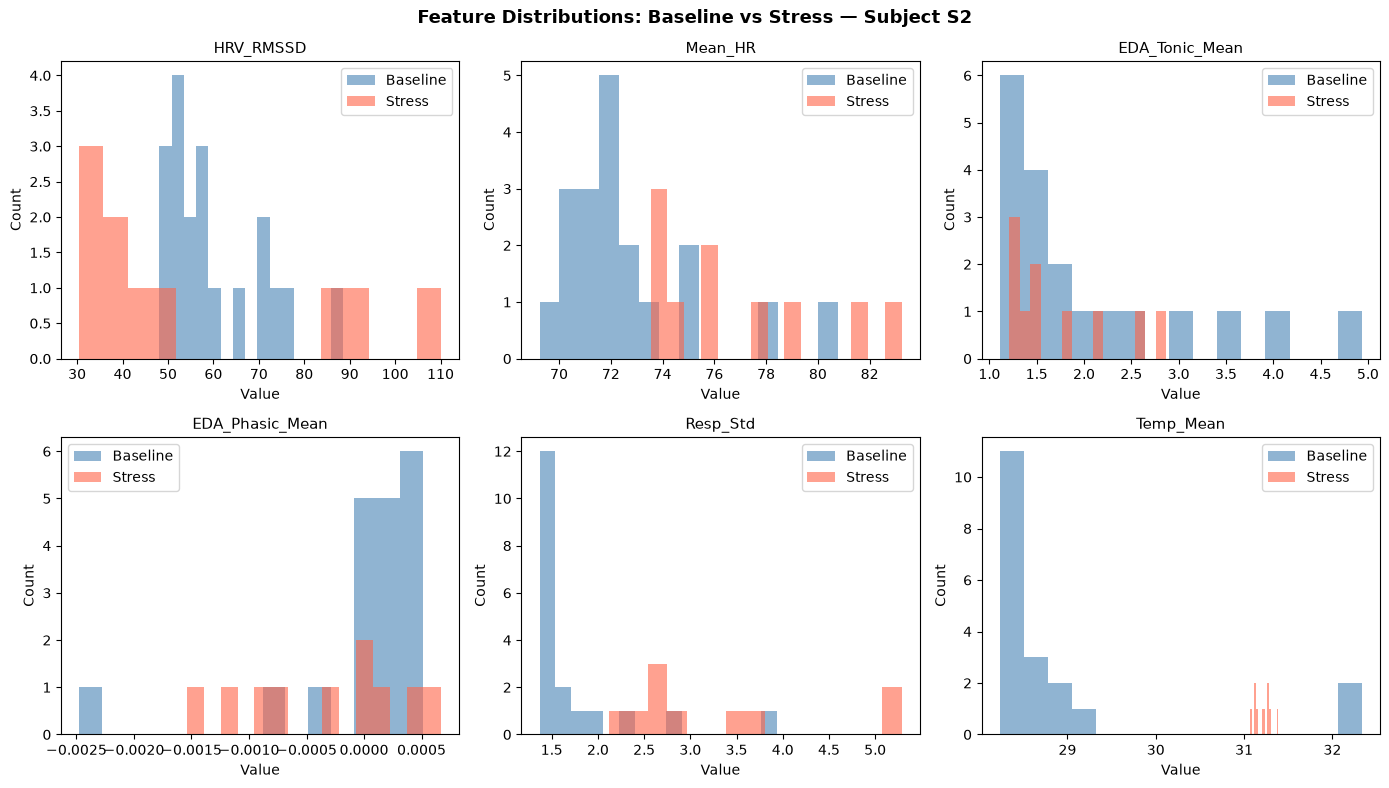

In [8]:
features_to_plot = ['HRV_RMSSD', 'Mean_HR', 'EDA_Tonic_Mean',
                    'EDA_Phasic_Mean', 'Resp_Std', 'Temp_Mean']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

label_map = {0: 'Baseline', 1: 'Stress'}
colors = {0: 'steelblue', 1: 'tomato'}

for i, feature in enumerate(features_to_plot):
    for label_val in [0, 1]:
        subset = feature_df[feature_df['Label'] == label_val][feature]
        axes[i].hist(subset, bins=15, alpha=0.6,
                     color=colors[label_val],
                     label=label_map[label_val])
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions: Baseline vs Stress — Subject S2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png', dpi=150)
plt.show()